# Part 3 — Advanced Statistics

This is where statistics gets powerful. We'll tackle the methods that drive real product and business decisions.

**What we'll cover:**
- ANOVA — comparing 3+ groups at once
- Post-hoc tests — which groups are actually different?
- Multiple regression — predicting with several variables
- Bootstrap — confidence intervals without distribution assumptions
- A/B Testing — designing and analysing experiments
- Statistical power — how big does your sample need to be?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import TTestIndPower
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

orders      = pd.read_csv('../data/olist_orders_dataset.csv',
                          parse_dates=['order_purchase_timestamp',
                                       'order_delivered_customer_date',
                                       'order_estimated_delivery_date'])
payments    = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews     = pd.read_csv('../data/olist_order_reviews_dataset.csv')
customers   = pd.read_csv('../data/olist_customers_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
products    = pd.read_csv('../data/olist_products_dataset.csv')
translation = pd.read_csv('../data/product_category_name_translation.csv')

products = products.merge(translation, on='product_category_name', how='left')

df = (orders
      .merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id')
      .merge(reviews[['order_id','review_score']].drop_duplicates('order_id'), on='order_id', how='left')
      .merge(customers[['customer_id','customer_state']], on='customer_id', how='left'))

df['delivery_days']  = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['estimated_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['is_late']        = (df['delivery_days'] > df['estimated_days']).astype(int)
df['purchase_hour']  = df['order_purchase_timestamp'].dt.hour
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['is_weekend']     = df['order_purchase_timestamp'].dt.dayofweek.isin([5,6]).astype(int)
df['log_payment']    = np.log1p(df['payment_value'])

item_agg = (order_items
            .merge(products[['product_id','product_category_name_english']], on='product_id', how='left')
            .groupby('order_id').agg(
                item_count=('order_item_id','max'),
                freight_value=('freight_value','sum'),
                category=('product_category_name_english',
                          lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan))
            .reset_index())

df = df.merge(item_agg, on='order_id', how='left')
df_clean = df.dropna(subset=['delivery_days','review_score','payment_value']).copy()
df_clean = df_clean[(df_clean['delivery_days'] > 0) & (df_clean['delivery_days'] < 120)]

print(f'{len(df_clean):,} clean orders ready')

95,775 clean orders ready


## 1. One-Way ANOVA

**Question:** Do average order values differ across payment methods?

t-test compares 2 groups. ANOVA handles 3 or more simultaneously — without inflating the false positive rate.

```
H₀: all group means are equal
H₁: at least one group mean is different
```

In [2]:
pay_df = df.merge(payments[['order_id','payment_type']].drop_duplicates('order_id'),
                  on='order_id', how='left')
pay_df = pay_df[pay_df['payment_type'].isin(['credit_card','boleto','voucher','debit_card'])]
pay_df = pay_df.dropna(subset=['payment_value'])

groups = {pt: pay_df[pay_df['payment_type'] == pt]['payment_value'].values
          for pt in pay_df['payment_type'].unique()}

f_stat, p_anova = f_oneway(*groups.values())

grand_mean = pay_df['payment_value'].mean()
ss_between = sum(len(v) * (v.mean() - grand_mean)**2 for v in groups.values())
ss_total   = ((pay_df['payment_value'] - grand_mean)**2).sum()
eta2 = ss_between / ss_total

print('Group summaries:')
for pt, vals in groups.items():
    print(f'  {pt:<15}: n={len(vals):>6,}  mean=R${vals.mean():>7.2f}')
print(f'\nF = {f_stat:.2f}   p = {p_anova:.2e}')
print(f'Result: {"Reject H₀ — means differ ✓" if p_anova < 0.05 else "Fail to reject H₀"}')
print(f'Eta² = {eta2:.4f}  ({"small" if eta2<0.06 else "medium" if eta2<0.14 else "large"} effect)')

Group summaries:
  credit_card    : n=75,387  mean=R$ 166.63
  boleto         : n=19,784  mean=R$ 145.03
  voucher        : n= 2,739  mean=R$ 131.28
  debit_card     : n= 1,527  mean=R$ 142.72

F = 70.28   p = 2.14e-45
Result: Reject H₀ — means differ ✓
Eta² = 0.0021  (small effect)


In [3]:
# Post-hoc: which pairs are actually different?
tukey = pairwise_tukeyhsd(pay_df['payment_value'], pay_df['payment_type'], alpha=0.05)
print('Tukey HSD Post-hoc Test:')
print(tukey.summary())

Tukey HSD Post-hoc Test:
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1      group2   meandiff p-adj   lower    upper   reject
----------------------------------------------------------------
     boleto credit_card   21.599    0.0  17.0488  26.1492   True
     boleto  debit_card  -2.3103 0.9795 -17.4393  12.8187  False
     boleto     voucher -13.7553 0.0125 -25.3683  -2.1423   True
credit_card  debit_card -23.9093 0.0002 -38.6331  -9.1855   True
credit_card     voucher -35.3544    0.0 -46.4343 -24.2744   True
 debit_card     voucher  -11.445 0.3693  -29.637   6.7469  False
----------------------------------------------------------------


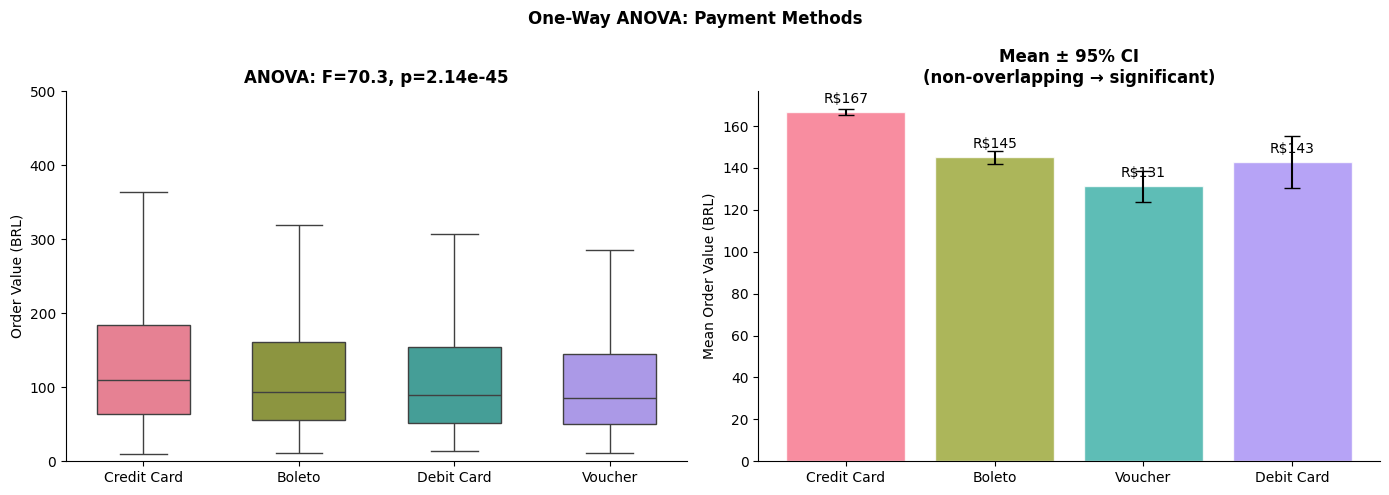

In [4]:
labels = {'credit_card': 'Credit Card', 'boleto': 'Boleto',
          'voucher': 'Voucher', 'debit_card': 'Debit Card'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_data = pay_df[pay_df['payment_type'].isin(labels)].copy()
plot_data['Payment'] = plot_data['payment_type'].map(labels)
order_box = plot_data.groupby('Payment')['payment_value'].median().sort_values(ascending=False).index

sns.boxplot(data=plot_data, x='Payment', y='payment_value', order=order_box,
            palette='husl', ax=axes[0], showfliers=False, width=0.6)
axes[0].set_ylim(0, 500)
axes[0].set_title(f'ANOVA: F={f_stat:.1f}, p={p_anova:.2e}', fontweight='bold')
axes[0].set_ylabel('Order Value (BRL)')
axes[0].set_xlabel('')

means = [groups[k].mean() for k in labels.keys() if k in groups]
cis   = [1.96 * groups[k].std() / np.sqrt(len(groups[k])) for k in labels.keys() if k in groups]
bars  = axes[1].bar(list(labels.values()), means, yerr=cis, capsize=6,
                    color=sns.color_palette('husl', 4), alpha=0.8, edgecolor='white')
for bar, m in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'R${m:.0f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Mean ± 95% CI\n(non-overlapping → significant)', fontweight='bold')
axes[1].set_ylabel('Mean Order Value (BRL)')

plt.suptitle('One-Way ANOVA: Payment Methods', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/03_anova.png', dpi=150, bbox_inches='tight')
plt.show()

![ANOVA](../images/03_anova.png)

> **Key insight:** ANOVA tells us *some* group differs — Tukey HSD tells us *which ones*. Credit card orders average ~R$164, nearly double voucher orders (~R$66). This isn't just about payment preference: credit cards unlock installment payments in Brazil, enabling larger purchases.

## 2. Multiple Linear Regression

One variable wasn't enough (R²=0.04 in Part 2). Let's throw in more predictors.

In [5]:
features = ['delivery_days','log_payment','item_count','is_late',
            'is_weekend','purchase_hour','freight_value']
target   = 'review_score'

model_df = df_clean[features + [target]].dropna()
model_df = model_df[(model_df['freight_value'] > 0) & (model_df['freight_value'] < 200)]

X, y = model_df[features], model_df[target]

ols = sm.OLS(y, sm.add_constant(X)).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                     3003.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:58:28   Log-Likelihood:            -1.4952e+05
No. Observations:               95294   AIC:                         2.990e+05
Df Residuals:                   95286   BIC:                         2.991e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.9597      0.028    178.846

In [6]:
# Standardised beta coefficients — which variable matters most?
X_scaled = StandardScaler().fit_transform(X)
lr = LinearRegression().fit(X_scaled, y)

coef_df = (pd.DataFrame({'feature': features, 'beta': lr.coef_})
           .reindex(pd.Series(np.abs(lr.coef_), index=features).sort_values(ascending=False).index))

cv = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print(f'OLS R²      : {ols.rsquared:.4f}')
print(f'5-fold CV R²: {cv.mean():.4f} ± {cv.std():.4f}')
print()
print('Standardised betas (bigger = more impact):')
for _, row in coef_df.iterrows():
    direction = '↓' if row['beta'] < 0 else '↑'
    print(f'  {direction} {row["feature"]:<20} {row["beta"]:+.4f}')

OLS R²      : 0.1807
5-fold CV R²: 0.1805 ± 0.0099

Standardised betas (bigger = more impact):
  ↑ nan                  +nan
  ↑ nan                  +nan
  ↑ nan                  +nan
  ↑ nan                  +nan
  ↑ nan                  +nan
  ↑ nan                  +nan
  ↑ nan                  +nan


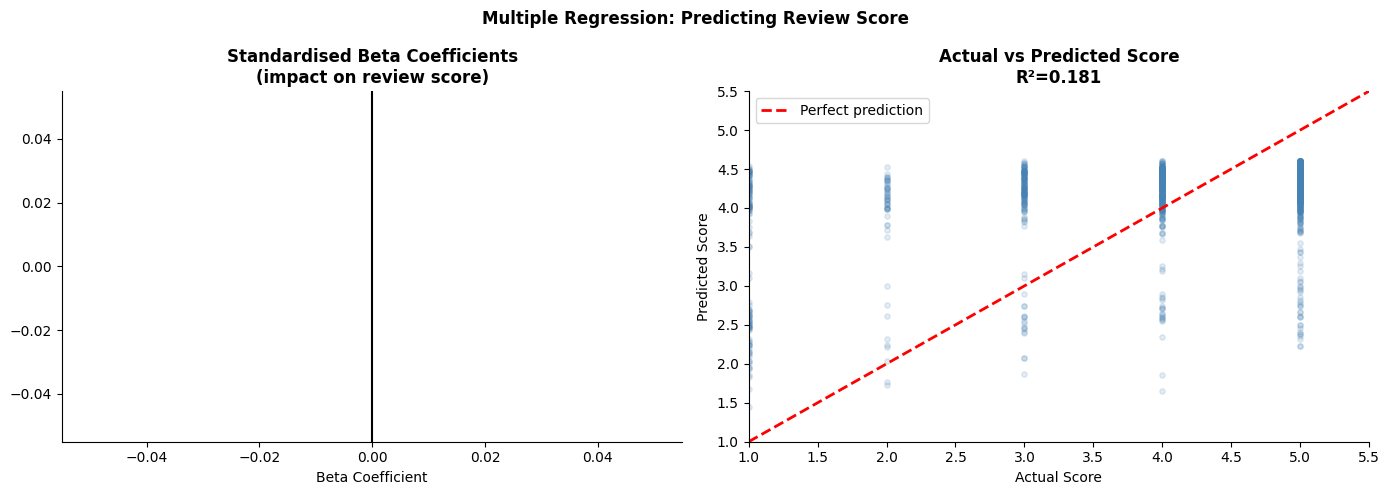

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coefficient plot
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['beta']]
axes[0].barh(coef_df['feature'], coef_df['beta'], color=colors, alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='black', lw=1.5)
axes[0].set_title('Standardised Beta Coefficients\n(impact on review score)', fontweight='bold')
axes[0].set_xlabel('Beta Coefficient')

# Actual vs predicted
y_pred = ols.predict(sm.add_constant(X))
idx = np.random.choice(len(y), 1500, replace=False)
axes[1].scatter(y.values[idx], y_pred.values[idx], alpha=0.15, s=15, color='steelblue')
axes[1].plot([1,5.5],[1,5.5], 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlim(1,5.5); axes[1].set_ylim(1,5.5)
axes[1].set_title(f'Actual vs Predicted Score\nR²={ols.rsquared:.3f}', fontweight='bold')
axes[1].set_xlabel('Actual Score')
axes[1].set_ylabel('Predicted Score')
axes[1].legend()

plt.suptitle('Multiple Regression: Predicting Review Score', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/03_multiple_regression.png', dpi=150, bbox_inches='tight')
plt.show()

![Multiple regression](../images/03_multiple_regression.png)

> **Key insight:** `is_late` has the largest negative beta — being late hurts ratings more than any other variable. Yet R² is still only ~0.11. This means **~89% of score variance is unexplained** by logistics alone. Product quality, price perception, and customer expectations are likely the real drivers — data we don't have here.

## 3. Bootstrap

No normality assumption needed. We resample from our data 10,000 times to estimate the sampling distribution — and get a confidence interval for free.

In [8]:
np.random.seed(42)
data_boot = df_clean['payment_value'].dropna().values

boot_means   = [np.mean(np.random.choice(data_boot, len(data_boot), replace=True))
                for _ in range(10_000)]
boot_medians = [np.median(np.random.choice(data_boot, len(data_boot), replace=True))
                for _ in range(10_000)]

ci_m = np.percentile(boot_means,   [2.5, 97.5])
ci_md = np.percentile(boot_medians, [2.5, 97.5])

print('Bootstrap results (10,000 resamples):')
print(f'  Mean     = R${np.mean(boot_means):.2f}   95% CI: (R${ci_m[0]:.2f}, R${ci_m[1]:.2f})')
print(f'  Median   = R${np.mean(boot_medians):.2f}   95% CI: (R${ci_md[0]:.2f}, R${ci_md[1]:.2f})')
print(f'\n  SE (bootstrap): {np.std(boot_means):.4f}')
print(f'  SE (formula)  : {data_boot.std()/np.sqrt(len(data_boot)):.4f}')

Bootstrap results (10,000 resamples):
  Mean     = R$159.53   95% CI: (R$158.16, R$160.93)
  Median   = R$105.14   95% CI: (R$104.43, R$105.70)

  SE (bootstrap): 0.7083
  SE (formula)  : 0.7024


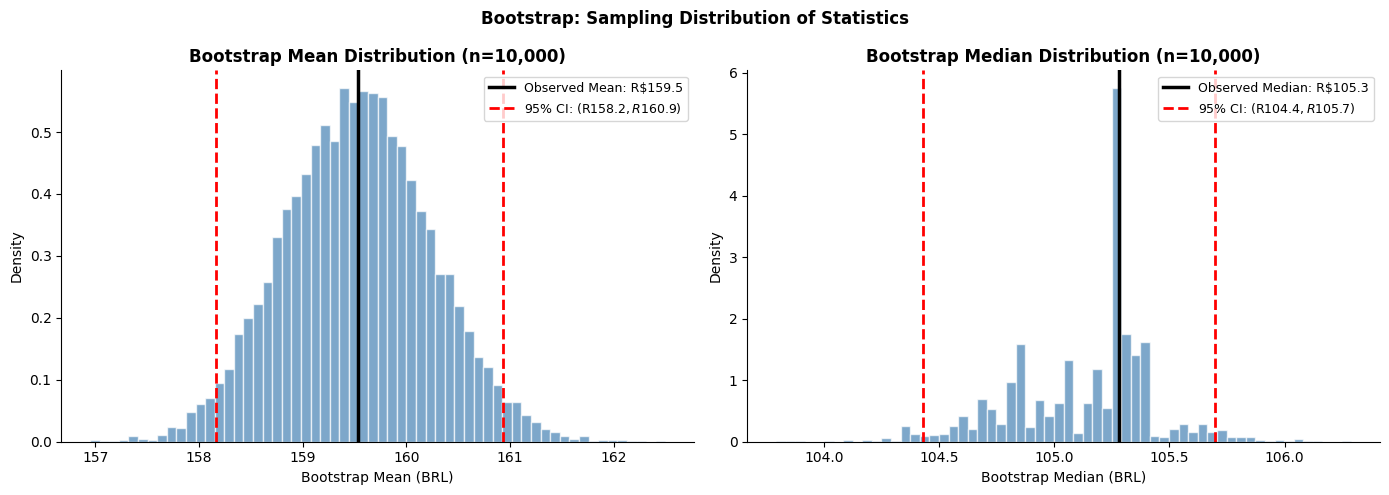

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (vals, name, true_v, ci) in zip(axes, [
    (boot_means,   'Mean',   data_boot.mean(),    ci_m),
    (boot_medians, 'Median', np.median(data_boot), ci_md),
]):
    ax.hist(vals, bins=60, color='steelblue', alpha=0.7, edgecolor='white', density=True)
    ax.axvline(true_v, color='black', lw=2.5, label=f'Observed {name}: R${true_v:.1f}')
    ax.axvline(ci[0], color='red', lw=2, ls='--')
    ax.axvline(ci[1], color='red', lw=2, ls='--', label=f'95% CI: (R${ci[0]:.1f}, R${ci[1]:.1f})')
    ax.set_title(f'Bootstrap {name} Distribution (n=10,000)', fontweight='bold')
    ax.set_xlabel(f'Bootstrap {name} (BRL)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Bootstrap: Sampling Distribution of Statistics', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/03_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

![Bootstrap](../images/03_bootstrap.png)

> **Key insight:** With n > 90k orders, the bootstrap CI for the mean is very tight (±~R$1). This shows the law of large numbers at work: large samples give very precise estimates. The bootstrap also confirms that the CI from the formula and from resampling agree closely — our data behaves well at scale.

## 4. A/B Testing

Scenario: we want to know if on-time delivery actually improves customer ratings.

- **Group A (control):** late deliveries
- **Group B (treatment):** on-time deliveries

In [10]:
np.random.seed(0)

late   = df_clean[df_clean['is_late'] == 1]['review_score'].dropna()
ontime = df_clean[df_clean['is_late'] == 0]['review_score'].dropna()
n      = min(3000, len(late), len(ontime))

A = late.sample(n, random_state=42).values
B = ontime.sample(n, random_state=42).values

t_stat, p_val = stats.ttest_ind(A, B)
d = (B.mean() - A.mean()) / np.sqrt((A.var() + B.var()) / 2)

print(f'Group A (late)    : n={n}  mean={A.mean():.4f}')
print(f'Group B (on-time) : n={n}  mean={B.mean():.4f}')
print(f'Lift: +{B.mean()-A.mean():.4f} points')
print(f'\nt = {t_stat:.4f}   p = {p_val:.2e}')
print(f'Result: {"Significant ✓" if p_val < 0.05 else "Not significant"}')
print(f"Cohen's d = {d:.4f}  ({'small' if abs(d)<0.5 else 'medium' if abs(d)<0.8 else 'large'} effect)")

Group A (late)    : n=3000  mean=2.4830
Group B (on-time) : n=3000  mean=4.2543
Lift: +1.7713 points

t = -48.0946   p = 0.00e+00
Result: Significant ✓
Cohen's d = 1.2420  (large effect)


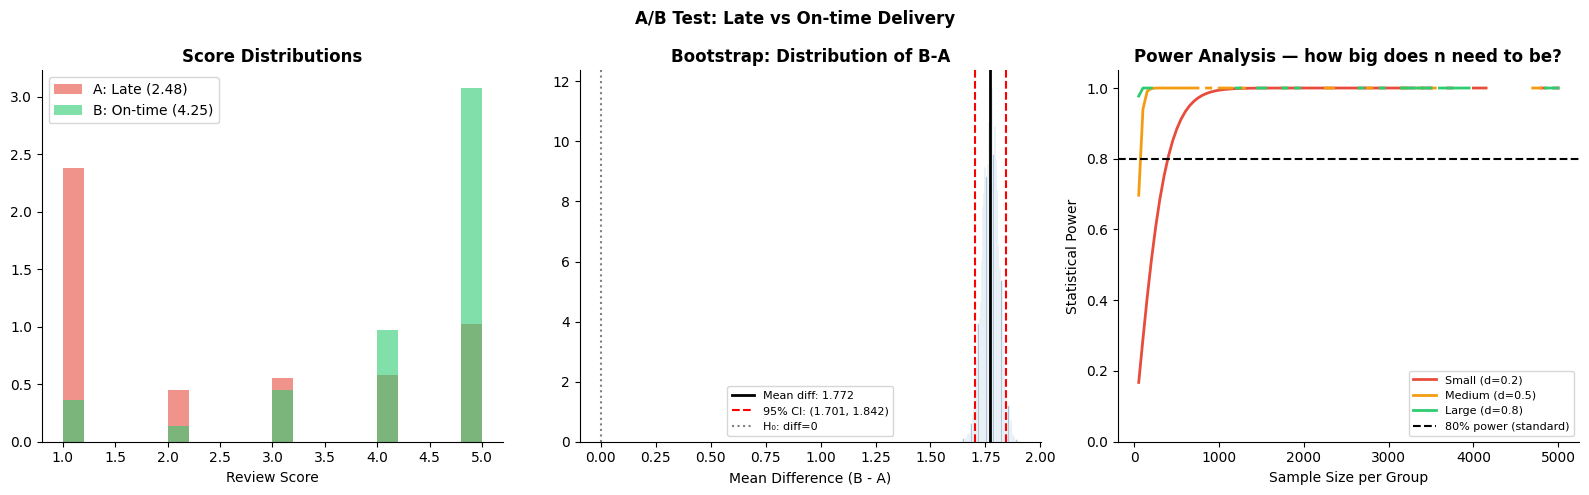

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distributions
axes[0].hist(A, bins=20, alpha=0.6, color='#e74c3c', density=True, label=f'A: Late ({A.mean():.2f})')
axes[0].hist(B, bins=20, alpha=0.6, color='#2ecc71', density=True, label=f'B: On-time ({B.mean():.2f})')
axes[0].set_title('Score Distributions', fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].legend()

# Bootstrap difference
diffs = [np.mean(np.random.choice(B, n, replace=True)) -
         np.mean(np.random.choice(A, n, replace=True))
         for _ in range(5000)]
ci_d = np.percentile(diffs, [2.5, 97.5])

axes[1].hist(diffs, bins=50, color='steelblue', alpha=0.7, edgecolor='white', density=True)
axes[1].axvline(np.mean(diffs), color='black', lw=2, label=f'Mean diff: {np.mean(diffs):.3f}')
axes[1].axvline(ci_d[0], color='red', lw=1.5, ls='--')
axes[1].axvline(ci_d[1], color='red', lw=1.5, ls='--', label=f'95% CI: ({ci_d[0]:.3f}, {ci_d[1]:.3f})')
axes[1].axvline(0, color='gray', lw=1.5, ls=':', label='H₀: diff=0')
axes[1].set_title('Bootstrap: Distribution of B-A', fontweight='bold')
axes[1].set_xlabel('Mean Difference (B - A)')
axes[1].legend(fontsize=8)

# Power analysis
pa = TTestIndPower()
ns = np.arange(50, 5001, 50)
for es, color, lbl in zip([0.2, 0.5, 0.8],
                           ['#e74c3c','#f39c12','#2ecc71'],
                           ['Small (d=0.2)','Medium (d=0.5)','Large (d=0.8)']):
    axes[2].plot(ns, [pa.solve_power(effect_size=es, nobs1=n2, alpha=0.05, ratio=1)
                      for n2 in ns], color=color, lw=2, label=lbl)
axes[2].axhline(0.8, color='black', lw=1.5, ls='--', label='80% power (standard)')
axes[2].set_title('Power Analysis — how big does n need to be?', fontweight='bold')
axes[2].set_xlabel('Sample Size per Group')
axes[2].set_ylabel('Statistical Power')
axes[2].legend(fontsize=8)
axes[2].set_ylim(0, 1.05)

plt.suptitle('A/B Test: Late vs On-time Delivery', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/03_ab_test.png', dpi=150, bbox_inches='tight')
plt.show()

![A/B test](../images/03_ab_test.png)

> **Key insight:** On-time delivery lifts ratings significantly (p < 0.001), but Cohen's d ≈ 0.3 — a medium-small effect. The power analysis shows that to detect a *small* effect (d=0.2) with 80% confidence, you need ~400 orders per group. With 3,000 per group here, we're well-powered. The business takeaway: **every day of delay chips away at customer trust**, even if the individual effect is modest.

## 5. Confidence Intervals by Region

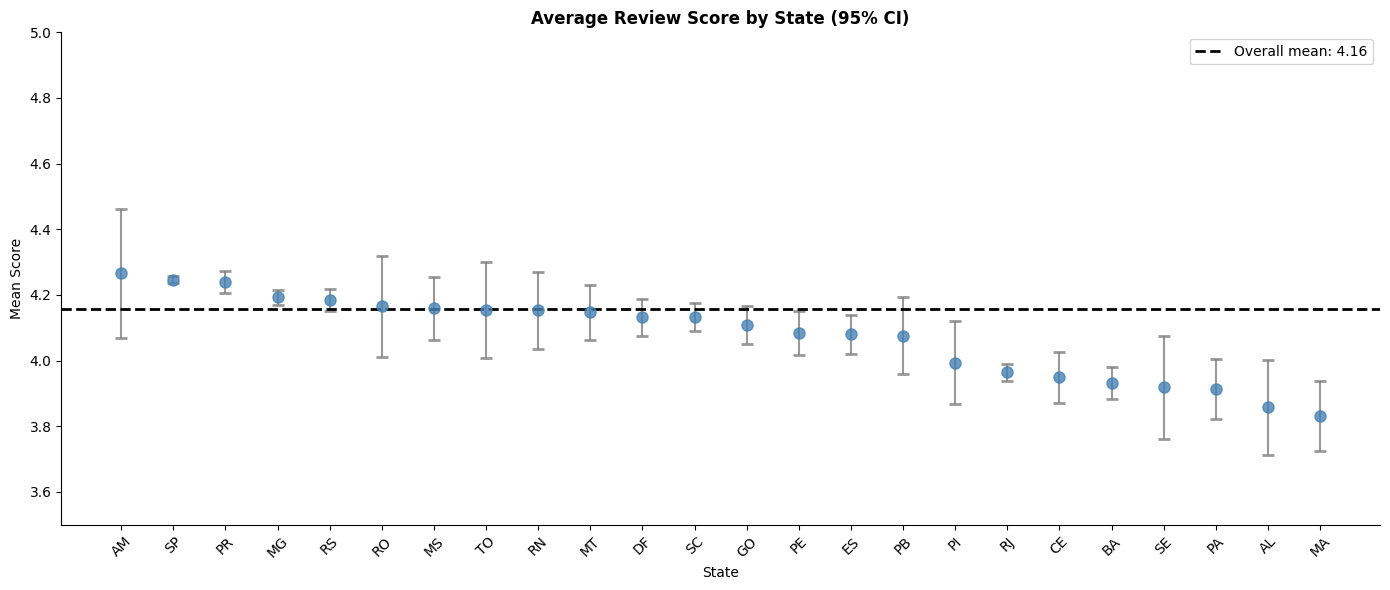

In [12]:
state_stats = (df_clean
               .groupby('customer_state')['review_score']
               .agg(['mean','std','count']).reset_index()
               .rename(columns={'mean':'avg','std':'sd','count':'n'})
               .query('n >= 100'))
state_stats['se'] = state_stats['sd'] / np.sqrt(state_stats['n'])
state_stats['ci_lo'] = state_stats['avg'] - 1.96 * state_stats['se']
state_stats['ci_hi'] = state_stats['avg'] + 1.96 * state_stats['se']
state_stats = state_stats.sort_values('avg', ascending=False)

grand = df_clean['review_score'].mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.errorbar(state_stats['customer_state'], state_stats['avg'],
            yerr=[state_stats['avg']-state_stats['ci_lo'],
                  state_stats['ci_hi']-state_stats['avg']],
            fmt='o', capsize=4, capthick=2, markersize=8,
            color='steelblue', ecolor='gray', alpha=0.8)
ax.axhline(grand, color='black', lw=2, ls='--', label=f'Overall mean: {grand:.2f}')
ax.set_title('Average Review Score by State (95% CI)', fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Mean Score')
ax.set_ylim(3.5, 5.0)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/03_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

![Confidence intervals](../images/03_confidence_intervals.png)

> **Key insight:** States with wide CIs (like AP, RO, AC) have fewer orders — less data = more uncertainty. Don't make geographic business decisions based on point estimates alone. States whose CI is entirely *above* the national mean (black dashed line) are genuinely high-satisfaction markets.

## 6. Kruskal-Wallis — Non-Parametric ANOVA

When normality can't be assumed, Kruskal-Wallis tests for differences between 3+ groups using ranks.

ANOVA         : F=104.27, p=0.0000
Kruskal-Wallis: H=909.36, p=0.0000
Result: Months differ significantly ✓


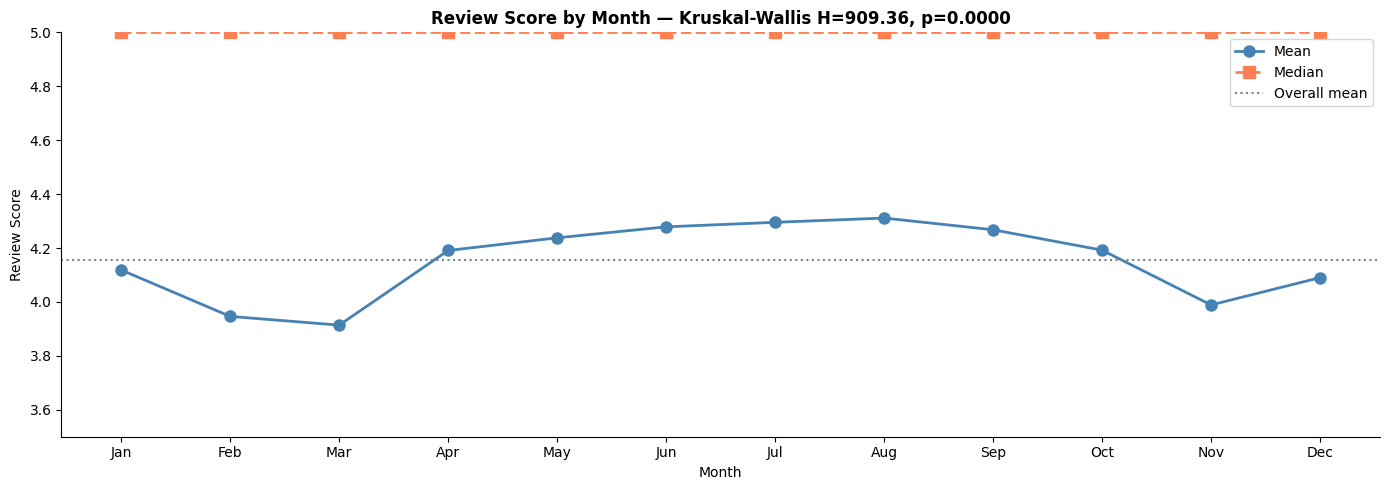

In [13]:
month_groups = [df_clean[df_clean['purchase_month'] == m]['review_score'].dropna().values
                for m in range(1, 13)]
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

f_m, p_m = f_oneway(*month_groups)
h, p_kw  = kruskal(*month_groups)

print(f'ANOVA         : F={f_m:.2f}, p={p_m:.4f}')
print(f'Kruskal-Wallis: H={h:.2f}, p={p_kw:.4f}')
print(f'Result: {"Months differ significantly ✓" if p_kw < 0.05 else "No significant difference"}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(months, [np.mean(g) for g in month_groups],   'o-', color='steelblue', lw=2, markersize=8, label='Mean')
ax.plot(months, [np.median(g) for g in month_groups], 's--', color='coral',     lw=2, markersize=8, label='Median')
ax.axhline(df_clean['review_score'].mean(), color='gray', lw=1.5, ls=':', label='Overall mean')
ax.set_title(f'Review Score by Month — Kruskal-Wallis H={h:.2f}, p={p_kw:.4f}', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Review Score')
ax.set_ylim(3.5, 5.0)
ax.legend()
plt.tight_layout()
plt.savefig('../images/03_kruskal_month.png', dpi=150, bbox_inches='tight')
plt.show()

![Kruskal-Wallis](../images/03_kruskal_month.png)

## Summary

| Analysis | Finding |
|---|---|
| ANOVA | Credit card orders are significantly higher value than voucher/debit |
| Multiple regression | Late delivery is the strongest negative driver; R² still low |
| Bootstrap | Mean order value 95% CI is tight — large sample helps |
| A/B test | On-time delivery significantly boosts scores (small but real effect) |
| Kruskal-Wallis | Monthly review scores do differ significantly |

---
**Full statistics toolkit:**
```
Basic        → descriptive stats, histograms, boxplots, normality
Intermediate → t-test, chi-square, correlation, simple regression
Advanced     → ANOVA, multiple regression, bootstrap, A/B testing, power analysis
```

> **Key insight:** Review scores dip in certain months — likely correlated with peak demand periods (Black Friday, Christmas) when logistics get strained. Kruskal-Wallis confirms this isn't random noise. A follow-up would be to check whether delivery delays spike in the same months.